In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from numpy import random
from InflGame.adaptive.visualization import Shell
import InflGame.utils.general as general
import InflGame.domains.rd as rd

## Resource distribution (beta)

In [2]:
#The resource points
bin_points=np.linspace(.001, .999, 100)





#resource parmaters
resource_parameters=[2,2] #alpha,beta

#Resource distribution
resource_distribution1=rd.resource_distribution_choice(bin_points=bin_points,resource_type='beta',resource_parameters=resource_parameters)

#Plot
domain=bin_points
fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(domain,resource_distribution1)
ax.set_box_aspect(1)
plt.title('Resource distribution')
plt.xlabel('loc')
plt.ylabel('Resource density')
plt.close()

## Resource distribution (Gaussian sym)

In [3]:
#The resource points
bin_points=np.linspace(.001, .999, 100)
 
#Resource parameters
resource_parameters_gaussian=[[.1,.1],[.25,.75],[1,1]] #[[sd1, sd2,], [mean1,mean2], [factor1,factor2]]
#Resource distribution
resource_distribution2=rd.resource_distribution_choice(bin_points=bin_points,resource_type='multi_modal_gaussian_distribution_1D',resource_parameters=resource_parameters_gaussian)

#Plot
domain=bin_points
fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(domain,resource_distribution2)
plt.title('Resource distribution')
plt.xlabel('loc')
plt.ylabel('Resource density')
ax.set_box_aspect(1) 
#fig.savefig('1d_bimodal_alpha_05.svg',bbox_inches='tight')
plt.close()


## Resource distribution (Gaussian asym)

In [4]:
#The resource points
bin_points=np.linspace(.001, .999, 100)
 
#Resource parameters
resource_parameters_gaussian=[[.1,.1],[.25,.75],[1,.6]] #[[sd1, sd2,], [mean1,mean2], [factor1,factor2]]
#Resource distribution
resource_distribution3=rd.resource_distribution_choice(bin_points=bin_points,resource_type='multi_modal_gaussian_distribution_1D',resource_parameters=resource_parameters_gaussian)

#Plot
domain=bin_points
fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(domain,resource_distribution3)
plt.title('Resource distribution')
plt.xlabel('loc')
plt.ylabel('Resource density')
ax.set_box_aspect(1) 
#fig.savefig('1d_bimodal_alpha_05.svg',bbox_inches='tight')
plt.close()

## Resource distribution (Noisy)

In [5]:
#The resource points
random.seed(1)
bin_points=np.linspace(.001, .999, 100)

#smoothing kernal (resource parameter)
def smooth(y, box_pts):
    box = np.ones(box_pts)/box_pts
    y_smooth = np.convolve(y, box, mode='same')
    return y_smooth
y=np.abs(random.uniform(low=0,high=1,size=100)+random.normal(loc=.5,scale=.1,size=100))

#Resource distribution
resource_distribution4=smooth(y,box_pts=20)
domain=bin_points

#Plot
fig, ax = plt.subplots(figsize=(12, 8))
ax.set_box_aspect(1)
ax.plot(domain,resource_distribution4)
plt.title('Resource distribution')
plt.xlabel('loc')
plt.ylabel('Resource density')
#fig.savefig('1d_bimodal_noisy.svg',bbox_inches='tight')
plt.close()

## Resource distribution (uniform)

In [6]:
#The resource points
bin_points=np.linspace(.001, .999, 100)
 
#Resource parameters
resource_parameters_gaussian=[[.1,.1],[.1,.5],[1,1]] #[[sd1, sd2,], [mean1,mean2], [factor1,factor2]]
#Resource distribution
resource_distribution5=rd.resource_distribution_choice(bin_points=bin_points,resource_type='multi_modal_gaussian_distribution_1D',resource_parameters=resource_parameters_gaussian)

#Plot
domain=bin_points
fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(domain,resource_distribution5)
plt.title('Resource distribution')
plt.xlabel('loc')
plt.ylabel('Resource density')
ax.set_box_aspect(1) 
#fig.savefig('1d_bimodal_alpha_05.svg',bbox_inches='tight')
plt.close()

In [7]:
#The resource points
bin_points=np.linspace(.001, .999, 100)

resource_distribution6=np.array([1]*len(bin_points))

#Plot
fig, ax = plt.subplots(figsize=(12, 8))
ax.set_box_aspect(1)
ax.plot(domain,resource_distribution6)
plt.title('Resource distribution')
plt.xlabel('loc')
plt.ylabel('Resource density')
plt.close()

In [8]:
# bin_points=np.array([0,1])


# resource_distribution7=np.array([10,10])

# #Plot
# fig, ax = plt.subplots(figsize=(12, 8))
# ax.vlines(bin_points, 0, resource_distribution7, colors='b', lw=5)
# ax.set_box_aspect(1)
# ax.scatter(bin_points,resource_distribution7)
# plt.title('Resource distribution')
# plt.xlabel('loc')
# plt.ylabel('Resource density')


## Setup:The enviroment and adapative enviroment

The cell below sets up the outer shell for visualizing the the adapative enviroment. 

In [9]:

domain_type='1d'
resource_distribution=resource_distribution3
mean=np.dot(bin_points,resource_distribution)/np.sum(resource_distribution) #mean of the resource distribution




num_agents=4 #number of agents
#int_agents_pos=general.agent_position_setup(num_agents=num_agents,setup_type='paper_default',domain_type=domain_type,domain_bounds=0)
int_agents_pos=torch.tensor([0.1,0.2,0.5, 0.9]) #initial agent positions

infl_configs={"infl_type":"beta"} # influence type of the agents


parameters=general.agent_parameter_setup(num_agents=num_agents,infl_type=infl_configs["infl_type"],setup_type="initial_symmetric_setup",reach=4) # parameters impacting agents reach (their std)
#parameters_custom=np.array([[.1,.2,.3,...]]) #needs to be length num_players


time_steps=20000# number steps for the adaptive dynamics


vis=Shell(num_agents=num_agents,agents_pos=int_agents_pos,parameters=parameters,resource_distribution=resource_distribution,bin_points=bin_points, 
infl_configs = {'infl_type': 'beta'}, learning_rate_type= 'cosine_annealing', learning_rate= [.0001, .0001, .08], time_steps=time_steps,
fp= 0, infl_cshift= False, cshift = 0, infl_fshift= False, Q = None,
domain_type = '1d', domain_bounds = [0, 1], resource_type = 'na', domain_refinement = 10,
tolerance = 10**-12, tolerated_agents = None,ignore_zero_infl= True)


vis.setup_adaptive_env()
vis.field.gradient_ascent()
og_pos_matrix=vis.field.pos_matrix
og_grad_matrix=vis.field.grad_matrix
vis.agents_pos=int_agents_pos.clone()
vis.field.agents_pos=int_agents_pos.clone()

        

#(0.158184517)
        




In [10]:
vis.field.pos_matrix[-1]

tensor([0.3856, 0.3856, 0.3857, 0.3857])

In [50]:
mean

np.float64(0.4378970608623551)

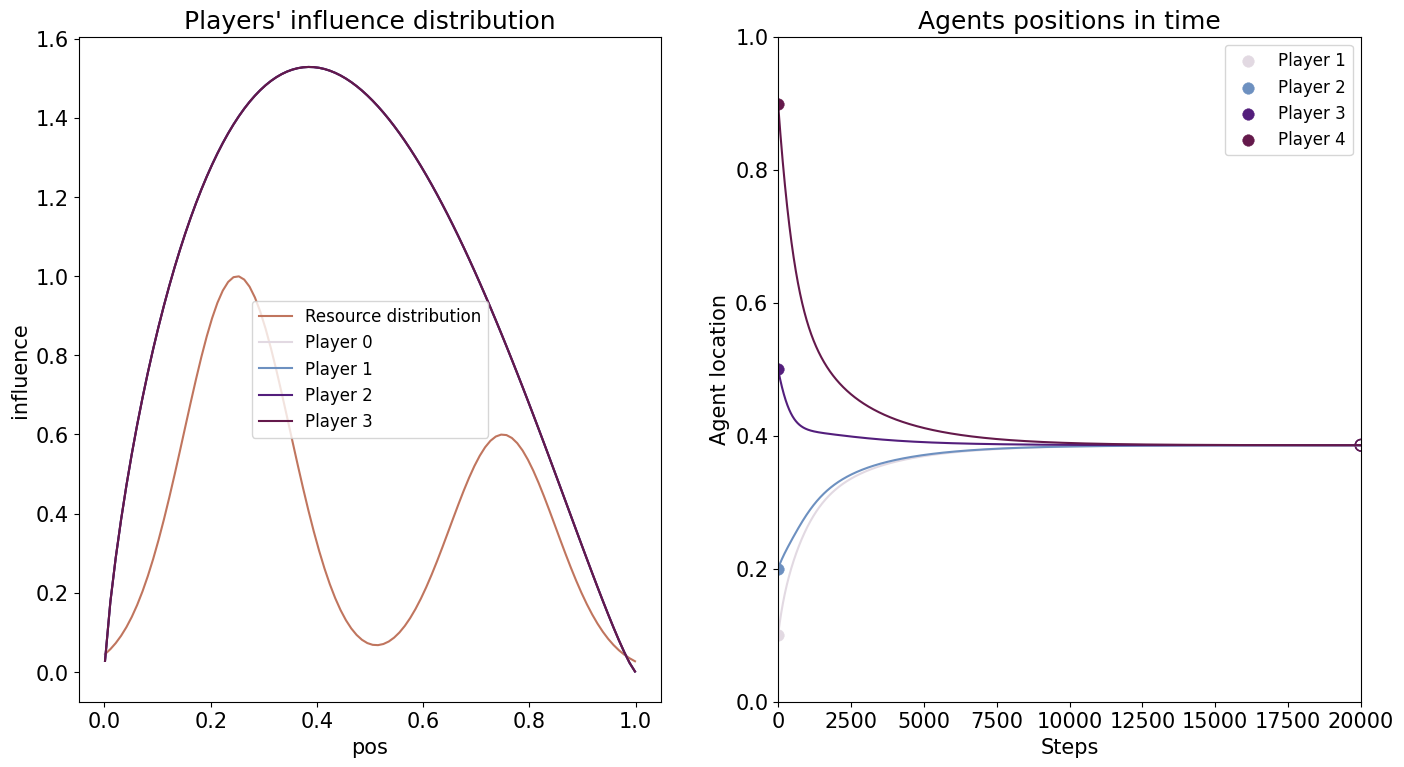

In [11]:
vis.dist_pos_gif(1)